In [ ]:
!pip install seaborn
!pip install tensorflow
!pip install rdkit
!pip install tqdm
!pip install lightgbm
!pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.1/37.1 MB 36.4 MB/s eta 0:00:00


In [ ]:

import pandas as pd
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator
from tqdm import tqdm
from sklearn.feature_selection import VarianceThreshold
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
import json


In [ ]:
df=pd.read_csv("master_toxocity_dataset.csv")

In [ ]:
cols = list(df.columns)
cols.insert(1, cols.pop(-1))
df = df[cols]

In [ ]:
df

,SMILES,scaffold,CYP450_CYP2C19,Respiratory_toxicity,CT_TOX,Developmental Toxicity,Hepatobiliary disorders,Metabolism and nutrition disorders,Product issues,Eye disorders,...,NR-ER,NR-ER-LBD,NR-PPAR-gamma,SR-ARE,SR-ATAD5,SR-HSE,SR-MMP,SR-p53,CYP450_CYP2C9,Cardiotoxicity
0,*C(=O)[C@H](CCCCNC(=O)OCCOC)NC(=O)OCCOC,NO_SCAFFOLD,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Br/C(=N\Nc1nnn[nH]1)c1ccncc1,C(=NNc1nnn[nH]1)c1ccncc1,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN
2,Br/C=C/Br,NO_SCAFFOLD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,BrC(Br)(Br)c1ccc2ccccc2n1,c1ccc2ncccc2c1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,BrC(Br)Br,NO_SCAFFOLD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42283,CCCCCCCC/C=C\CCCCCCCCCC(=O)OC[C@H](COP(=O)(O)O...,NO_SCAFFOLD,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
42284,CCCCCCCC(=O)OC[C@H](COP(=O)(O)OC[C@H](O)COP(=O...,NO_SCAFFOLD,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
42285,CC/C=C\C/C=C\C/C=C\C/C=C\C/C=C\CCCC(=O)OC[C@H]...,NO_SCAFFOLD,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
42286,CC(C)CCCCCCCCCCCCCCCCCCCCC(=O)O[C@H](COC(=O)CC...,NO_SCAFFOLD,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42288 entries, 0 to 42287
Data columns (total 57 columns):
 #   Column                                                               Non-Null Count  Dtype  
---  ------                                                               --------------  -----  
 0   SMILES                                                               42288 non-null  object 
 1   scaffold                                                             42288 non-null  object 
 2   CYP450_CYP2C19                                                       15345 non-null  float64
 3   Respiratory_toxicity                                                 6155 non-null   float64
 4   CT_TOX                                                               6272 non-null   float64
 5   Developmental Toxicity                                               5007 non-null   float64
 6   Hepatobiliary disorders                                              6212 non-null   float64
 7   Meta

In [ ]:

columns_to_keep = [

    'SMILES', 'scaffold',
    'Hepatotoxic', 'Cardiotoxicity', 'Respiratory_toxicity', 'BBBP_toxicity',
     'Mutagenicity',
    'Carcinogenicity', 'Eye Corrosion', 'Eye Irritation'
    'CYP450_CYP1A2', 'CYP450_CYP2C9', 'CYP450_CYP2C19', 'CYP450_CYP2D6', 'CYP450_CYP3A4',



]

# Clean the dataset
df_clean = df[columns_to_keep].copy()

print(f"Original shape: {df.shape}")
print(f"Cleaned shape: {df_clean.shape}")

Original shape: (42288, 57)
Cleaned shape: (42288, 15)


In [ ]:
non_label_cols = ['SMILES', 'scaffold'] # stores all non label names
label_cols = [col for col in df_clean.columns if col not in non_label_cols] # stores all the label column

min_ratio = 0.1

good_labels = []
dropped_labels = []

for col in label_cols:
    ratio = df_clean[col].notna().mean()  # find mean of not null values in that column

    if ratio >= min_ratio:
        good_labels.append(col)
    else:
        dropped_labels.append(col)

print("Kept:", len(good_labels))
print("Dropped:", len(dropped_labels))

Kept: 13
Dropped: 0


In [ ]:
print(good_labels)
print(dropped_labels)

['Hepatotoxic', 'Cardiotoxicity', 'Respiratory_toxicity', 'BBBP_toxicity', 'Mutagenicity', 'Carcinogenicity', 'Eye Corrosion', 'Eye Irritation', 'CYP450_CYP1A2', 'CYP450_CYP2C9', 'CYP450_CYP2C19', 'CYP450_CYP2D6', 'CYP450_CYP3A4']
[]


In [ ]:
df_clean.drop(columns=dropped_labels, inplace=True)

In [ ]:
df_clean

,SMILES,scaffold,Hepatotoxic,Cardiotoxicity,Respiratory_toxicity,BBBP_toxicity,Mutagenicity,Carcinogenicity,Eye Corrosion,Eye Irritation,CYP450_CYP1A2,CYP450_CYP2C9,CYP450_CYP2C19,CYP450_CYP2D6,CYP450_CYP3A4
0,*C(=O)[C@H](CCCCNC(=O)OCCOC)NC(=O)OCCOC,NO_SCAFFOLD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Br/C(=N\Nc1nnn[nH]1)c1ccncc1,C(=NNc1nnn[nH]1)c1ccncc1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,NaN,NaN
2,Br/C=C/Br,NO_SCAFFOLD,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,BrC(Br)(Br)c1ccc2ccccc2n1,c1ccc2ncccc2c1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
4,BrC(Br)Br,NO_SCAFFOLD,1.0,NaN,NaN,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42283,CCCCCCCC/C=C\CCCCCCCCCC(=O)OC[C@H](COP(=O)(O)O...,NO_SCAFFOLD,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
42284,CCCCCCCC(=O)OC[C@H](COP(=O)(O)OC[C@H](O)COP(=O...,NO_SCAFFOLD,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
42285,CC/C=C\C/C=C\C/C=C\C/C=C\C/C=C\CCCC(=O)OC[C@H]...,NO_SCAFFOLD,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
42286,CC(C)CCCCCCCCCCCCCCCCCCCCC(=O)O[C@H](COC(=O)CC...,NO_SCAFFOLD,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
def generate_morgan_df(smiles_list, radius=2, nBits=2048):
    """Generates a DataFrame of Morgan fingerprints for a list of SMILES strings."""
    print("Generating Morgan Fingerprints...")
    generator = GetMorganGenerator(radius=radius, fpSize=nBits)

    fp_array = []


    for smi in tqdm(smiles_list, desc="Morgan FPs"):
        mol = Chem.MolFromSmiles(smi)
        if mol:
            fp = generator.GetFingerprintAsNumPy(mol)
        else:
            fp = np.zeros(nBits)
        fp_array.append(fp)

    fp_array = np.array(fp_array)


    fp_cols = [f"FP_{i}" for i in range(nBits)]

    df_fp = pd.DataFrame(fp_array, columns=fp_cols)

    return df_fp, generator

In [ ]:
print(generate_morgan_df(["*C(=O)[C@H](CCCCNC(=O)OCCOC)NC(=O)OCCOC"]))

Generating Morgan Fingerprints...


Morgan FPs: 100%|██████████| 1/1 [00:00<00:00, 25.08it/s]

(   FP_0  FP_1  FP_2  FP_3  FP_4  FP_5  FP_6  FP_7  FP_8  FP_9  ...  FP_2038  \
0     0     1     0     0     0     0     0     0     0     0  ...        0   

   FP_2039  FP_2040  FP_2041  FP_2042  FP_2043  FP_2044  FP_2045  FP_2046  \
0        0        0        0        0        0        0        0        0   

   FP_2047  
0        0  

[1 rows x 2048 columns], <rdkit.Chem.rdFingerprintGenerator.FingerprintGenerator64 object at 0x78b280fc8660>)


In [ ]:
descriptor_names = [desc[0] for desc in Descriptors._descList]

def generate_descriptor_df(smiles_list):
    """Generates a DataFrame of molecular descriptors for a list of SMILES strings."""
    print("Calculating Descriptors...")
    desc_data = []


    for smi in tqdm(smiles_list, desc="Descriptors"):
        mol = Chem.MolFromSmiles(smi)
        if mol:
            values = [getattr(Descriptors, name)(mol) for name in descriptor_names]
        else:
            values = [0.0] * len(descriptor_names)

        desc_data.append(values)

    df_desc = pd.DataFrame(desc_data, columns=descriptor_names)


    df_desc = df_desc.replace([np.inf, -np.inf], [1e6, -1e6])
    df_desc = df_desc.fillna(0.0)

    return df_desc

In [ ]:
print(generate_descriptor_df(["*C(=O)[C@H](CCCCNC(=O)OCCOC)NC(=O)OCCOC"]))

Calculating Descriptors...


Descriptors: 100%|██████████| 1/1 [00:00<00:00, 11.15it/s]

   MaxAbsEStateIndex  MaxEStateIndex  MinAbsEStateIndex  MinEStateIndex  \
0          11.642626       11.642626           0.102432       -0.606208   

        qed   SPS    MolWt  HeavyAtomMolWt  ExactMolWt  NumValenceElectrons  \
0  0.467548  12.0  333.361         308.161  333.166176                  133   

   ...  fr_sulfide  fr_sulfonamd  fr_sulfone  fr_term_acetylene  fr_tetrazole  \
0  ...           0             0           0                  0             0   

   fr_thiazole  fr_thiocyan  fr_thiophene  fr_unbrch_alkane  fr_urea  
0            0            0             0                 1        0  

[1 rows x 217 columns]


In [ ]:
df_fp, morgan_generator = generate_morgan_df(df_clean["SMILES"])
df_desc = generate_descriptor_df(df_clean["SMILES"])

# Combine
X_df = pd.concat([df_fp, df_desc], axis=1)
print("Final shape:", X_df.shape)
print("Example columns:", X_df.columns[:10])

Generating Morgan Fingerprints...


Morgan FPs: 100%|██████████| 42288/42288 [00:14<00:00, 2821.16it/s]


Calculating Descriptors...


Descriptors: 100%|██████████| 42288/42288 [16:32<00:00, 42.60it/s]


Final shape: (42288, 2265)
Example columns: Index(['FP_0', 'FP_1', 'FP_2', 'FP_3', 'FP_4', 'FP_5', 'FP_6', 'FP_7', 'FP_8',
       'FP_9'],
      dtype='object')


In [ ]:
X_df

,FP_0,FP_1,FP_2,FP_3,FP_4,FP_5,FP_6,FP_7,FP_8,FP_9,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42283,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,17,0
42284,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,31,0
42285,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,11,0
42286,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,41,0


In [ ]:
final_dataset = pd.concat([df_clean, X_df], axis=1)

In [ ]:
final_dataset.to_csv("final(real)_dataset.csv", index=False)

In [ ]:
final_dataset

,SMILES,scaffold,Hepatotoxic,Cardiotoxicity,Respiratory_toxicity,BBBP_toxicity,Mutagenicity,Carcinogenicity,Eye Corrosion,Eye Irritation,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,*C(=O)[C@H](CCCCNC(=O)OCCOC)NC(=O)OCCOC,NO_SCAFFOLD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,1,0
1,Br/C(=N\Nc1nnn[nH]1)c1ccncc1,C(=NNc1nnn[nH]1)c1ccncc1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,0,0,1,0,0,0,0,0
2,Br/C=C/Br,NO_SCAFFOLD,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
3,BrC(Br)(Br)c1ccc2ccccc2n1,c1ccc2ncccc2c1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,...,0,0,0,0,0,0,0,0,0,0
4,BrC(Br)Br,NO_SCAFFOLD,1.0,NaN,NaN,1.0,1.0,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42283,CCCCCCCC/C=C\CCCCCCCCCC(=O)OC[C@H](COP(=O)(O)O...,NO_SCAFFOLD,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,17,0
42284,CCCCCCCC(=O)OC[C@H](COP(=O)(O)OC[C@H](O)COP(=O...,NO_SCAFFOLD,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,31,0
42285,CC/C=C\C/C=C\C/C=C\C/C=C\C/C=C\CCCC(=O)OC[C@H]...,NO_SCAFFOLD,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,11,0
42286,CC(C)CCCCCCCCCCCCCCCCCCCCC(=O)O[C@H](COC(=O)CC...,NO_SCAFFOLD,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,41,0


In [ ]:
core_cols = ['SMILES', 'scaffold']
feature_cols = X_df.columns.tolist()
label_cols = [col for col in df_clean.columns if col not in core_cols]
new_column_order = core_cols + feature_cols + label_cols


final_dataset = final_dataset[new_column_order]




In [ ]:
final_dataset

,SMILES,scaffold,FP_0,FP_1,FP_2,FP_3,FP_4,FP_5,FP_6,FP_7,...,BBBP_toxicity,Mutagenicity,Carcinogenicity,Eye Corrosion,Eye Irritation,CYP450_CYP1A2,CYP450_CYP2C9,CYP450_CYP2C19,CYP450_CYP2D6,CYP450_CYP3A4
0,*C(=O)[C@H](CCCCNC(=O)OCCOC)NC(=O)OCCOC,NO_SCAFFOLD,0,1,0,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Br/C(=N\Nc1nnn[nH]1)c1ccncc1,C(=NNc1nnn[nH]1)c1ccncc1,0,0,0,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,NaN,NaN
2,Br/C=C/Br,NO_SCAFFOLD,0,0,0,0,0,0,0,0,...,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,BrC(Br)(Br)c1ccc2ccccc2n1,c1ccc2ncccc2c1,0,0,0,0,0,0,0,0,...,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
4,BrC(Br)Br,NO_SCAFFOLD,0,1,0,0,0,0,0,0,...,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42283,CCCCCCCC/C=C\CCCCCCCCCC(=O)OC[C@H](COP(=O)(O)O...,NO_SCAFFOLD,0,1,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
42284,CCCCCCCC(=O)OC[C@H](COP(=O)(O)OC[C@H](O)COP(=O...,NO_SCAFFOLD,0,1,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
42285,CC/C=C\C/C=C\C/C=C\C/C=C\C/C=C\CCCC(=O)OC[C@H]...,NO_SCAFFOLD,0,1,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
42286,CC(C)CCCCCCCCCCCCCCCCCCCCC(=O)O[C@H](COC(=O)CC...,NO_SCAFFOLD,0,1,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
final_dataset= final_dataset[final_dataset["scaffold"].notna()]

In [ ]:
final_dataset

,SMILES,scaffold,FP_0,FP_1,FP_2,FP_3,FP_4,FP_5,FP_6,FP_7,...,BBBP_toxicity,Mutagenicity,Carcinogenicity,Eye Corrosion,Eye Irritation,CYP450_CYP1A2,CYP450_CYP2C9,CYP450_CYP2C19,CYP450_CYP2D6,CYP450_CYP3A4
0,*C(=O)[C@H](CCCCNC(=O)OCCOC)NC(=O)OCCOC,NO_SCAFFOLD,0,1,0,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Br/C(=N\Nc1nnn[nH]1)c1ccncc1,C(=NNc1nnn[nH]1)c1ccncc1,0,0,0,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,NaN,NaN
2,Br/C=C/Br,NO_SCAFFOLD,0,0,0,0,0,0,0,0,...,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,BrC(Br)(Br)c1ccc2ccccc2n1,c1ccc2ncccc2c1,0,0,0,0,0,0,0,0,...,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
4,BrC(Br)Br,NO_SCAFFOLD,0,1,0,0,0,0,0,0,...,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42283,CCCCCCCC/C=C\CCCCCCCCCC(=O)OC[C@H](COP(=O)(O)O...,NO_SCAFFOLD,0,1,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
42284,CCCCCCCC(=O)OC[C@H](COP(=O)(O)OC[C@H](O)COP(=O...,NO_SCAFFOLD,0,1,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
42285,CC/C=C\C/C=C\C/C=C\C/C=C\C/C=C\CCCC(=O)OC[C@H]...,NO_SCAFFOLD,0,1,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
42286,CC(C)CCCCCCCCCCCCCCCCCCCCC(=O)O[C@H](COC(=O)CC...,NO_SCAFFOLD,0,1,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
unique_scaffolds = final_dataset["scaffold"].unique()

In [ ]:
np.random.shuffle(unique_scaffolds)

In [ ]:
train_cut = int(0.8 * len(unique_scaffolds))
val_cut = int(0.9 * len(unique_scaffolds))

train_scaffolds = unique_scaffolds[:train_cut]
val_scaffolds = unique_scaffolds[train_cut:val_cut]
test_scaffolds = unique_scaffolds[val_cut:]

In [ ]:
train_df = final_dataset[final_dataset["scaffold"].isin(train_scaffolds)]
val_df = final_dataset[final_dataset["scaffold"].isin(val_scaffolds)]
test_df = final_dataset[final_dataset["scaffold"].isin(test_scaffolds)]

In [ ]:
test_df

,SMILES,scaffold,FP_0,FP_1,FP_2,FP_3,FP_4,FP_5,FP_6,FP_7,...,BBBP_toxicity,Mutagenicity,Carcinogenicity,Eye Corrosion,Eye Irritation,CYP450_CYP1A2,CYP450_CYP2C9,CYP450_CYP2C19,CYP450_CYP2D6,CYP450_CYP3A4
0,*C(=O)[C@H](CCCCNC(=O)OCCOC)NC(=O)OCCOC,NO_SCAFFOLD,0,1,0,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Br/C=C/Br,NO_SCAFFOLD,0,0,0,0,0,0,0,0,...,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,BrC(Br)Br,NO_SCAFFOLD,0,1,0,0,0,0,0,0,...,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,BrC(Br)C(Br)(Br)Br,NO_SCAFFOLD,0,1,0,0,0,0,0,0,...,NaN,0.0,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
6,BrC(Br)C(Br)Br,NO_SCAFFOLD,0,1,0,0,0,0,0,0,...,NaN,0.0,NaN,NaN,1.0,NaN,NaN,NaN,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42283,CCCCCCCC/C=C\CCCCCCCCCC(=O)OC[C@H](COP(=O)(O)O...,NO_SCAFFOLD,0,1,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
42284,CCCCCCCC(=O)OC[C@H](COP(=O)(O)OC[C@H](O)COP(=O...,NO_SCAFFOLD,0,1,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
42285,CC/C=C\C/C=C\C/C=C\C/C=C\C/C=C\CCCC(=O)OC[C@H]...,NO_SCAFFOLD,0,1,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
42286,CC(C)CCCCCCCCCCCCCCCCCCCCC(=O)O[C@H](COC(=O)CC...,NO_SCAFFOLD,0,1,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
train_df

,SMILES,scaffold,FP_0,FP_1,FP_2,FP_3,FP_4,FP_5,FP_6,FP_7,...,BBBP_toxicity,Mutagenicity,Carcinogenicity,Eye Corrosion,Eye Irritation,CYP450_CYP1A2,CYP450_CYP2C9,CYP450_CYP2C19,CYP450_CYP2D6,CYP450_CYP3A4
3,BrC(Br)(Br)c1ccc2ccccc2n1,c1ccc2ncccc2c1,0,0,0,0,0,0,0,0,...,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
8,BrC(c1cccc2ccccc12)c1cccc2ccccc12,c1ccc2c(Cc3cccc4ccccc34)cccc2c1,0,1,0,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0,0.0
9,BrC(c1ccccc1)(c1ccccc1)c1ccccc1,c1ccc(C(c2ccccc2)c2ccccc2)cc1,0,0,0,0,0,0,0,0,...,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN
13,BrC1C=CCCC1,C1=CCCCC1,0,0,0,0,0,0,0,0,...,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
14,BrC1CCC(Br)C(Br)CCC(Br)C(Br)CCC1Br,C1CCCCCCCCCCC1,0,0,0,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42255,CC(=O)N[C@H]1[C@H](O[C@H]2[C@H](O)[C@@H](NC(C)...,C1CC[C@@H](O[C@H]2CCCO[C@@H]2OC[C@@H]2C[C@H](O...,0,1,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
42260,CCCCC/C=C\C/C=C\C/C=C\C/C=C\CCCC(=O)O[C@@H]1CO...,O=C1CCC/C=C\C[C@H]2CCCCCC[C@@H](CO[PH](=O)O[PH...,0,1,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
42263,CCCCCCCCCCCCCCC=COC[C@H](COP(=O)(O)O)OC(=O)CCC...,C1CCCC1,0,1,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
42266,CC(=CCCC(C)CCCC(C)C)C(=O)SCCNC(=O)CCNC(=O)C(O)...,c1ncc2ncn(C3CCCO3)c2n1,0,1,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
feature_cols = X_df.columns.tolist()
metadata_and_features = ["SMILES", "scaffold"] + feature_cols

X_train = train_df[feature_cols]
y_train = train_df.drop(columns=metadata_and_features)


X_val = val_df[feature_cols]
y_val = val_df.drop(columns=metadata_and_features)


X_test = test_df[feature_cols]
y_test = test_df.drop(columns=metadata_and_features)


print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}, y_val shape: {y_val.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

X_train shape: (24399, 2265), y_train shape: (24399, 13)
X_val shape: (3177, 2265), y_val shape: (3177, 13)
X_test shape: (14712, 2265), y_test shape: (14712, 13)


In [ ]:
selector = VarianceThreshold(threshold=0.01)
X_train_selected = selector.fit_transform(X_train)
X_val_selected = selector.transform(X_val)
X_test_selected = selector.transform(X_test)

kept_columns = selector.get_feature_names_out(X_train.columns)


/usr/local/lib/python3.12/dist-packages/numpy/lib/_nanfunctions_impl.py:1887: RuntimeWarning: overflow encountered in multiply
  sqr = np.multiply(arr, arr, out=arr, where=where)


In [ ]:
X_train_clean = pd.DataFrame(X_train_selected, columns=kept_columns, index=X_train.index)
X_val_clean = pd.DataFrame(X_val_selected, columns=kept_columns, index=X_val.index)
X_test_clean = pd.DataFrame(X_test_selected, columns=kept_columns, index=X_test.index)

In [ ]:
X_train_selected

array([[ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [ 1.,  0.,  0., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       ...,
       [ 1.,  0.,  0., ...,  0., 15.,  0.],
       [ 1.,  0.,  0., ...,  0.,  0.,  0.],
       [ 0.,  0.,  1., ...,  0.,  0.,  0.]])

In [ ]:
print(kept_columns)
kept_columns.shape

['FP_1' 'FP_2' 'FP_4' ... 'fr_thiophene' 'fr_unbrch_alkane' 'fr_urea']


(1097,)

<Axes: xlabel='None', ylabel='MolWt'>

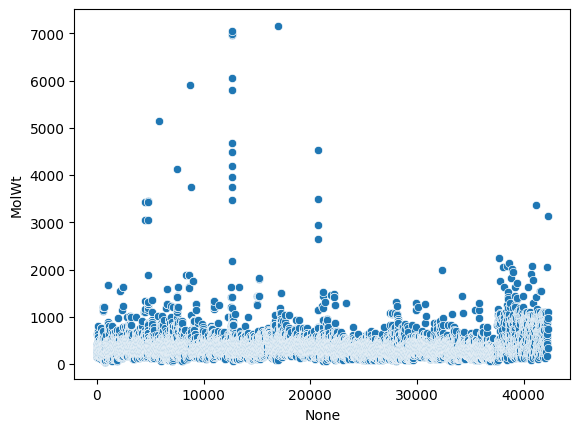

In [ ]:
sns.scatterplot(x=X_train_clean.index, y=X_train_clean["MolWt"])

<Axes: xlabel='None', ylabel='Kappa3'>

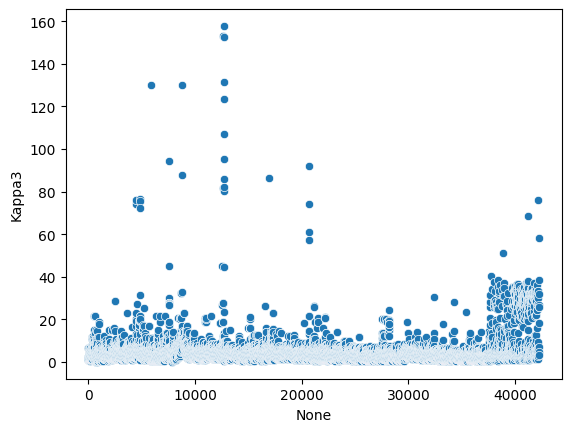

In [ ]:
sns.scatterplot(x=X_train_clean.index, y=X_train_clean["Kappa3"])

<Axes: xlabel='None', ylabel='NumAliphaticHeterocycles'>

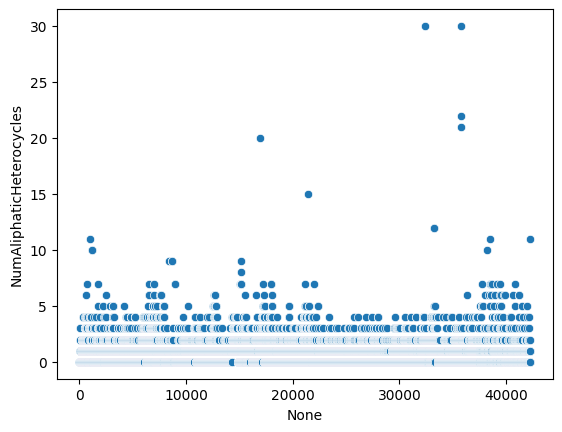

In [ ]:
sns.scatterplot(x=X_train_clean.index, y=X_train_clean["NumAliphaticHeterocycles"])

<Axes: xlabel='None', ylabel='fr_para_hydroxylation'>

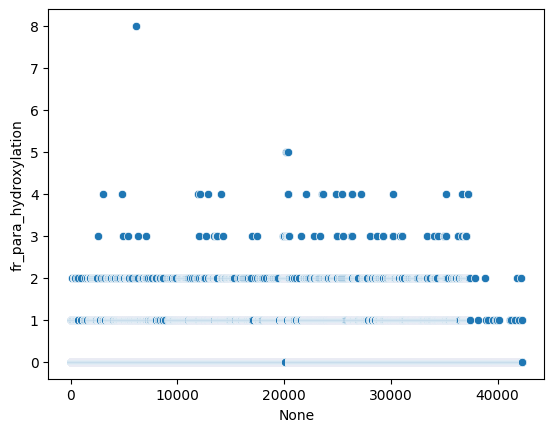

In [ ]:
sns.scatterplot(x=X_train_clean.index, y=X_train_clean["fr_para_hydroxylation"])

WE CAN SEE ALL THE DATAS ARE IN DIFFERENT DIFFERENT RANGE SO WE WILL SCALE IT

<Axes: ylabel='MolWt'>

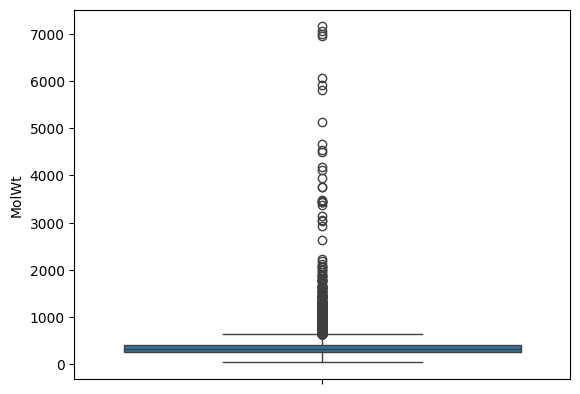

In [ ]:
sns.boxplot(
    y=X_train_clean["MolWt"]

)

<Axes: ylabel='Kappa3'>

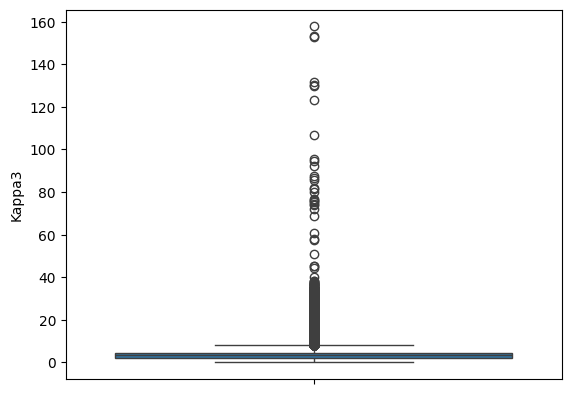

In [ ]:
sns.boxplot(
    y=X_train_clean["Kappa3"],

)

<Axes: xlabel='MolWt', ylabel='Count'>

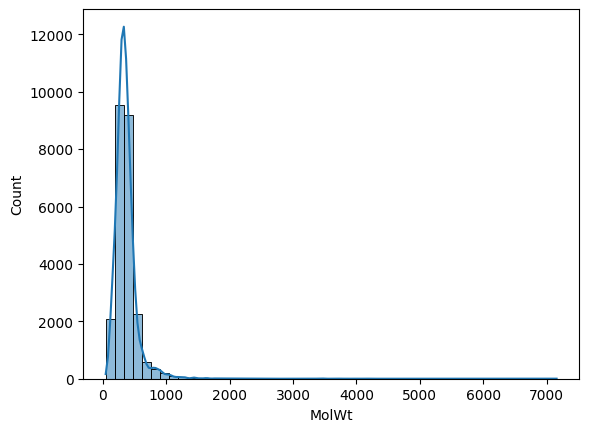

In [ ]:
sns.histplot(X_train_clean["MolWt"], bins=50, kde=True)

THIS IS RIGHT SKEWED

In [ ]:
X_train_log = X_train_clean.copy()
X_val_log = X_val_clean.copy()
X_test_log = X_test_clean.copy()

In [ ]:
#columns for log transformation
fingerprints_cols = [col for col in X_train_clean.columns if col.startswith('FP_')]
desc_cols = [col for col in X_train_clean.columns if col not in fingerprints_cols]
cols_to_log = []
for col in desc_cols:
    # Check if the minimum value in the training set is >= 0
    if X_train_clean[col].min() >= 0:
        cols_to_log.append(col)

In [ ]:
#  Apply the log transform ONLY to those specific columns
for col in cols_to_log:
    X_train_log[col] = np.log1p(X_train_clean[col])
    X_val_log[col]   = np.log1p(X_val_clean[col])
    X_test_log[col]  = np.log1p(X_test_clean[col])

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [ ]:
from sklearn.preprocessing import StandardScaler
import numpy as np # Ensure numpy is imported

fingerprints_cols = [col for col in X_train_clean.columns if col.startswith('FP_')]
desc_cols = [col for col in X_train_clean.columns if col not in fingerprints_cols]

# Replace infinite values (which might have been created by np.log1p) with NaN,
# then fill any NaN values (including those just created) with 0
for df_log in [X_train_log, X_val_log, X_test_log]:
    df_log.replace([np.inf, -np.inf], np.nan, inplace=True)


scaler = StandardScaler()

#scaling only the descriptor columns, leaving the binary fingerprint columns unchanged
X_train_desc_scaled = scaler.fit_transform(X_train_log[desc_cols])
X_val_desc_scaled = scaler.transform(X_val_log[desc_cols])
X_test_desc_scaled = scaler.transform(X_test_log[desc_cols])

# Convert back to DataFrames with original column names and indices
X_train_desc_scaled = pd.DataFrame(X_train_desc_scaled, columns=desc_cols, index=X_train_log.index)
X_val_desc_scaled = pd.DataFrame(X_val_desc_scaled, columns=desc_cols, index=X_val_log.index)
X_test_desc_scaled = pd.DataFrame(X_test_desc_scaled, columns=desc_cols, index=X_test_log.index)

# 5. Recombine the unscaled fingerprints with the newly scaled descriptors
X_train_ann = pd.concat([X_train_log[fingerprints_cols], X_train_desc_scaled], axis=1)
X_val_ann = pd.concat([X_val_log[fingerprints_cols], X_val_desc_scaled], axis=1)
X_test_ann = pd.concat([X_test_log[fingerprints_cols], X_test_desc_scaled], axis=1)

In [ ]:
X_train_ann

,FP_1,FP_2,FP_4,FP_5,FP_7,FP_8,FP_9,FP_12,FP_13,FP_14,...,fr_priamide,fr_pyridine,fr_quatN,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_thiazole,fr_thiophene,fr_unbrch_alkane,fr_urea
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.126079,2.399629,-0.181721,-0.270413,-0.222892,-0.100397,-0.155557,-0.19476,-0.197511,-0.190913
8,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.126079,-0.383116,-0.181721,-0.270413,-0.222892,-0.100397,-0.155557,-0.19476,-0.197511,-0.190913
9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.126079,-0.383116,-0.181721,-0.270413,-0.222892,-0.100397,-0.155557,-0.19476,-0.197511,-0.190913
13,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.126079,-0.383116,-0.181721,-0.270413,-0.222892,-0.100397,-0.155557,-0.19476,-0.197511,-0.190913
14,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.126079,-0.383116,-0.181721,-0.270413,-0.222892,-0.100397,-0.155557,-0.19476,-0.197511,-0.190913
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42255,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,-0.126079,-0.383116,-0.181721,-0.270413,-0.222892,-0.100397,-0.155557,-0.19476,-0.197511,-0.190913
42260,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.126079,-0.383116,-0.181721,-0.270413,-0.222892,-0.100397,-0.155557,-0.19476,5.144518,-0.190913
42263,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.126079,-0.383116,-0.181721,-0.270413,-0.222892,-0.100397,-0.155557,-0.19476,7.413966,-0.190913
42266,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,-0.126079,-0.383116,-0.181721,3.365399,-0.222892,-0.100397,-0.155557,-0.19476,-0.197511,-0.190913


In [ ]:
X_val_ann

,FP_1,FP_2,FP_4,FP_5,FP_7,FP_8,FP_9,FP_12,FP_13,FP_14,...,fr_priamide,fr_pyridine,fr_quatN,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_thiazole,fr_thiophene,fr_unbrch_alkane,fr_urea
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.126079,2.399629,-0.181721,-0.270413,-0.222892,-0.100397,-0.155557,-0.19476,-0.197511,-0.190913
10,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.126079,-0.383116,-0.181721,-0.270413,-0.222892,-0.100397,-0.155557,-0.19476,-0.197511,-0.190913
78,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.126079,-0.383116,-0.181721,-0.270413,-0.222892,-0.100397,-0.155557,-0.19476,-0.197511,-0.190913
82,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.126079,-0.383116,-0.181721,-0.270413,-0.222892,-0.100397,-0.155557,-0.19476,-0.197511,-0.190913
98,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.126079,-0.383116,-0.181721,-0.270413,-0.222892,-0.100397,-0.155557,-0.19476,-0.197511,-0.190913
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42039,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.126079,-0.383116,-0.181721,-0.270413,-0.222892,-0.100397,-0.155557,-0.19476,-0.197511,-0.190913
42120,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,-0.126079,-0.383116,-0.181721,-0.270413,-0.222892,-0.100397,-0.155557,-0.19476,5.834442,-0.190913
42142,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,-0.126079,-0.383116,-0.181721,-0.270413,-0.222892,-0.100397,-0.155557,-0.19476,5.511097,-0.190913
42146,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.126079,-0.383116,-0.181721,-0.270413,-0.222892,-0.100397,-0.155557,-0.19476,-0.197511,-0.190913


<Axes: xlabel='None', ylabel='MolWt'>

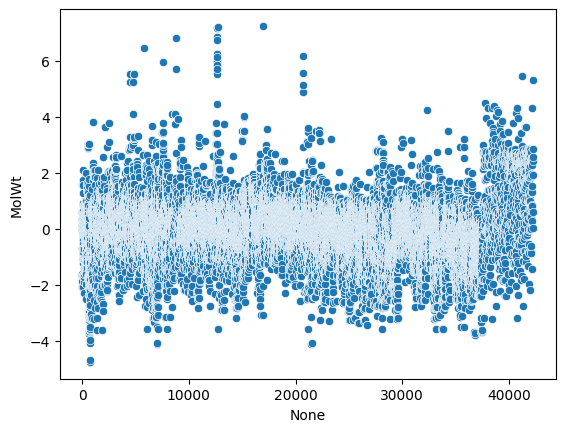

In [ ]:
sns.scatterplot(x=X_train_ann.index, y=X_train_ann["MolWt"])

<Axes: ylabel='MolWt'>

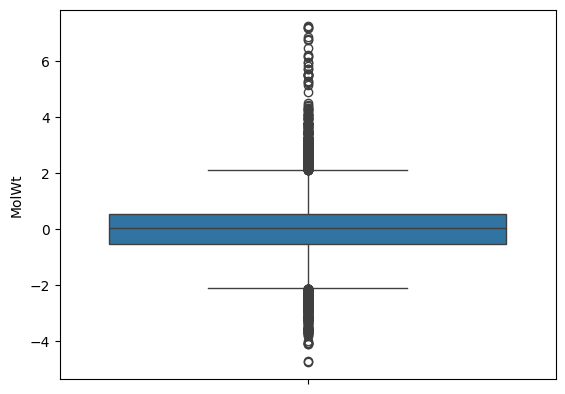

In [ ]:
sns.boxplot(
    y=X_train_ann["MolWt"]

)

<Axes: xlabel='MolWt', ylabel='Count'>

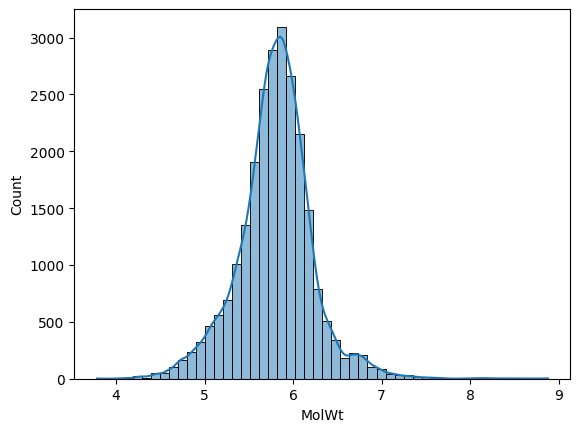

In [ ]:
sns.histplot(X_train_log["MolWt"], bins=50, kde=True)

In [ ]:
X_train_np = X_train_ann.to_numpy(dtype=np.float32)
X_val_np = X_val_ann.to_numpy(dtype=np.float32)
X_test_np = X_test_ann.to_numpy(dtype=np.float32)

y_train_np = y_train.to_numpy(dtype=np.float32)
y_val_np = y_val.to_numpy(dtype=np.float32)
y_test_np = y_test.to_numpy(dtype=np.float32)

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

model = Sequential([

    Dense(128, activation='relu', input_shape=(X_train_ann.shape[1],), kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.2),

    Dense(13, activation='sigmoid')
])



In [ ]:
#Count the number of Positives (1s) and Negatives (0s) for each of the 32 columns
# We use nansum to completely ignore the missing tests
pos_counts = np.nansum(y_train_np == 1.0, axis=0)
neg_counts = np.nansum(y_train_np == 0.0, axis=0)

# Calculate the Positive Weight for each column (Negatives / Positives)
# We add a tiny number (1e-7) to the bottom so Python doesn't crash if a column has zero 1s
pos_weights = neg_counts / (pos_counts + 1e-7)



# 3. Convert it to a TensorFlow constant so the GPU can use it incredibly fast
tf_pos_weights = tf.constant(pos_weights, dtype=tf.float32)

print("Calculated Weights for 13 labels!")
print("Example Weight for Label 0:", pos_weights[2])

Calculated Weights for 13 labels!
Example Weight for Label 0: 2.2297029698555044


In [ ]:
import tensorflow as tf

def masked_bce_loss(y_true, y_pred):
    """
    Computes Binary Crossentropy but completely ignores NaN values in y_true.
    """
    y_true = tf.cast(y_true, tf.float32)
    mask = tf.cast(tf.math.logical_not(tf.math.is_nan(y_true)), tf.float32)
    y_true_safe = tf.where(tf.math.is_nan(y_true), tf.zeros_like(y_true), y_true)
    raw_loss = tf.keras.backend.binary_crossentropy(y_true_safe, y_pred)
    weight_mask = (y_true_safe * tf_pos_weights) + (1.0 - y_true_safe)
    weighted_loss = raw_loss * weight_mask
    masked_loss = weighted_loss * mask
    return tf.reduce_sum(masked_loss, axis=-1) / (tf.reduce_sum(mask, axis=-1) + 1e-7)

In [ ]:
# Compile the Model with the Custom Masked Loss
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=masked_bce_loss,
    metrics=[

        tf.keras.metrics.AUC(multi_label=True, name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)




In [ ]:
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
early_stopper = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [ ]:
lr_reducer = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

In [ ]:
history = model.fit(
    X_train_np,
    y_train_np,
    validation_data=(X_val_np, y_val_np),
    epochs=100,
    batch_size=64,
    callbacks=[early_stopper, lr_reducer],
    verbose=1
)

Epoch 1/100
382/382 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - auc: 0.6384 - loss: 0.8811 - precision: 0.9107 - recall: 0.5354 - val_auc: 0.6589 - val_loss: 0.7247 - val_precision: 0.9278 - val_recall: 0.5508 - learning_rate: 0.0010
Epoch 2/100
382/382 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - auc: 0.6816 - loss: 0.6788 - precision: 0.9339 - recall: 0.5272 - val_auc: 0.6633 - val_loss: 0.6573 - val_precision: 0.9344 - val_recall: 0.5322 - learning_rate: 0.0010
Epoch 3/100
382/382 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - auc: 0.6915 - loss: 0.6085 - precision: 0.9392 - recall: 0.5192 - val_auc: 0.6906 - val_loss: 0.5998 - val_precision: 0.9424 - val_recall: 0.5445 - learning_rate: 0.0010
Epoch 4/100
382/382 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - auc: 0.6978 - loss: 0.5737 - precision: 0.9426 - recall: 0.5180 - val_auc: 0.6803 - val_loss: 0.5997 - val_precision: 0.9390 - val_recall: 0.5422 - learning_rate: 0.0010
Epoch 5/100
382/382 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - auc: 0.6973 - loss: 0.5571 - precision: 0.9

In [ ]:
y_val_pred_prob = model.predict(X_val_np)

100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [ ]:
from sklearn.metrics import fbeta_score
import numpy as np

best_thresholds_strict = []
BETA = 0.7

for i in range(y_val_np.shape[1]):

    y_true = y_val_np[:, i]
    y_pred_prob = y_val_pred_prob[:, i]

    # Remove NaNs
    mask = ~np.isnan(y_true)
    y_true = y_true[mask]
    y_pred_prob = y_pred_prob[mask]

    best_t = 0.5
    best_fbeta = 0

    for t in np.arange(0.1, 0.9, 0.05):
        preds = (y_pred_prob > t).astype(int)

        if len(np.unique(y_true)) < 2:
            continue  # skip bad labels

        # THE FIX: Use F-Beta instead of F1
        fbeta = fbeta_score(y_true, preds, beta=BETA, zero_division=0)

        if fbeta > best_fbeta:
            best_fbeta = fbeta
            best_t = t

    best_thresholds_strict.append(best_t)

print(f"Best thresholds per label (Optimized for F{BETA}):")
print(best_thresholds_strict)

threshold_dict = {label: float(thresh) for label, thresh in zip(label_cols, best_thresholds_strict)}

# Save it securely
with open('optimal_thresholds.json', 'w') as f:
    json.dump(threshold_dict, f, indent=4)

print("Optimal F0.7 thresholds safely stored to optimal_thresholds.json")






Best thresholds per label (Optimized for F0.7):
[np.float64(0.5500000000000002), np.float64(0.8000000000000002), np.float64(0.7500000000000002), np.float64(0.8500000000000002), np.float64(0.6500000000000001), np.float64(0.8500000000000002), np.float64(0.8500000000000002), np.float64(0.7500000000000002), np.float64(0.7000000000000002), np.float64(0.7500000000000002), np.float64(0.7000000000000002), np.float64(0.7500000000000002), np.float64(0.6500000000000001)]
Optimal F0.7 thresholds safely stored to optimal_thresholds.json


In [ ]:
y_val_pred = np.zeros_like(y_val_pred_prob)

for i, t in enumerate(best_thresholds_strict):
    y_val_pred[:, i] = (y_val_pred_prob[:, i] > t).astype(int)

In [ ]:
from sklearn.metrics import precision_score, recall_score

# Apply the new strict thresholds
y_val_pred_strict = np.zeros_like(y_val_pred_prob)

for i, t in enumerate(best_thresholds_strict):
    y_val_pred_strict[:, i] = (y_val_pred_prob[:, i] > t).astype(int)

precision_list = []
recall_list = []
fbeta_list = []

for i in range(y_val_np.shape[1]):

    y_true = y_val_np[:, i]
    y_pred = y_val_pred_strict[:, i]

    # Remove NaNs
    mask = ~np.isnan(y_true)
    y_true = y_true[mask]
    y_pred = y_pred[mask]

    if len(np.unique(y_true)) < 2:
        precision_list.append(np.nan)
        recall_list.append(np.nan)
        fbeta_list.append(np.nan)
        continue

    precision_list.append(precision_score(y_true, y_pred, zero_division=0))
    recall_list.append(recall_score(y_true, y_pred, zero_division=0))
    fbeta_list.append(fbeta_score(y_true, y_pred, beta=BETA, zero_division=0))

# Print the final report
for i, name in enumerate(label_cols):
    print(f"{name}:")
    print(f"  Threshold: {best_thresholds_strict[i]:.2f}")
    print(f"  Precision: {precision_list[i]:.3f}")
    print(f"  Recall:    {recall_list[i]:.3f}")
    print(f"  F{BETA}:      {fbeta_list[i]:.3f}")
    print("------")

Hepatotoxic:
  Threshold: 0.55
  Precision: 0.570
  Recall:    0.775
  F0.7:      0.624
------
Cardiotoxicity:
  Threshold: 0.80
  Precision: 0.856
  Recall:    0.845
  F0.7:      0.852
------
Respiratory_toxicity:
  Threshold: 0.75
  Precision: 0.732
  Recall:    0.712
  F0.7:      0.726
------
BBBP_toxicity:
  Threshold: 0.85
  Precision: 0.878
  Recall:    0.830
  F0.7:      0.862
------
Mutagenicity:
  Threshold: 0.65
  Precision: 0.831
  Recall:    0.839
  F0.7:      0.833
------
Carcinogenicity:
  Threshold: 0.85
  Precision: 0.514
  Recall:    0.750
  F0.7:      0.574
------
Eye Corrosion:
  Threshold: 0.85
  Precision: 0.522
  Recall:    1.000
  F0.7:      0.619
------
Eye Irritation:
  Threshold: 0.75
  Precision: 0.865
  Recall:    0.934
  F0.7:      0.886
------
CYP450_CYP1A2:
  Threshold: 0.70
  Precision: 0.870
  Recall:    0.818
  F0.7:      0.853
------
CYP450_CYP2C9:
  Threshold: 0.75
  Precision: 0.796
  Recall:    0.706
  F0.7:      0.764
------
CYP450_CYP2C19:
  Thre

In [ ]:
import joblib
import json

#  Save the Keras Neural Network
model.save('toxicity_model.h5')

#  Save the Scaler
joblib.dump(scaler, 'desc_scaler.pkl')

#  Save the exact column order and metadata
pipeline_metadata = {
    'fingerprints_cols': fingerprints_cols,
    'desc_cols': desc_cols,
    'cols_to_log': cols_to_log,
    'label_names': list(label_cols)
}

with open('pipeline_metadata.json', 'w') as f:
    json.dump(pipeline_metadata, f, indent=4)


In [ ]:
from sklearn.metrics import precision_score, recall_score, fbeta_score

# 1. Predict raw probabilities on the unseen TEST set
y_test_pred_prob = model.predict(X_test_np)

# 2. Apply the strict thresholds you just learned from the VAL set
y_test_pred_strict = np.zeros_like(y_test_pred_prob)
for i, t in enumerate(best_thresholds_strict):
    y_test_pred_strict[:, i] = (y_test_pred_prob[:, i] > t).astype(int)

# 3. Generate the true Final Exam report
print("TRUE UNBIASED TEST SET PERFORMANCE ")
for i, name in enumerate(label_cols):
    y_true = y_test_np[:, i]
    y_pred = y_test_pred_strict[:, i]

    # Remove NaNs
    mask = ~np.isnan(y_true)
    y_true = y_true[mask]
    y_pred = y_pred[mask]

    if len(np.unique(y_true)) < 2:
        continue

    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f07 = fbeta_score(y_true, y_pred, beta=0.7, zero_division=0)

    print(f"{name}:")
    print(f"  Applied Val Threshold: {best_thresholds_strict[i]:.2f}")
    print(f"  True Test Precision:   {precision:.3f}")
    print(f"  True Test Recall:      {recall:.3f}")
    print(f"  True Test F0.7:        {f07:.3f}")
    print("------")

460/460 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
--- 🏆 TRUE UNBIASED TEST SET PERFORMANCE (F0.7) ---
Hepatotoxic:
  Applied Val Threshold: 0.55
  True Test Precision:   0.436
  True Test Recall:      0.776
  True Test F0.7:        0.509
------
Cardiotoxicity:
  Applied Val Threshold: 0.80
  True Test Precision:   0.907
  True Test Recall:      0.700
  True Test F0.7:        0.827
------
Respiratory_toxicity:
  Applied Val Threshold: 0.75
  True Test Precision:   0.627
  True Test Recall:      0.777
  True Test F0.7:        0.669
------
BBBP_toxicity:
  Applied Val Threshold: 0.85
  True Test Precision:   0.713
  True Test Recall:      0.734
  True Test F0.7:        0.720
------
Mutagenicity:
  Applied Val Threshold: 0.65
  True Test Precision:   0.716
  True Test Recall:      0.631
  True Test F0.7:        0.685
------
Carcinogenicity:
  Applied Val Threshold: 0.85
  True Test Precision:   0.491
  True Test Recall:      0.628
  True Test F0.7:        0.529
------
Eye Corrosion:
  Applied Val T